### Install nixtla's SDK

In [1]:
# !pip install nixtla pandas python-dotenv matplotlib

### Import libraries and load data

In [2]:
import pandas as pd
from nixtla import NixtlaClient

### Forecast using TimeGPT in 3 easy steps

In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_key_nixtla")

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/anaconda3/envs/nixtla_env/lib/python3.13/site-packages/nixtla/nixtla_client.py:382: UserWarning: `df` contains the following exogenous features: ['index'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


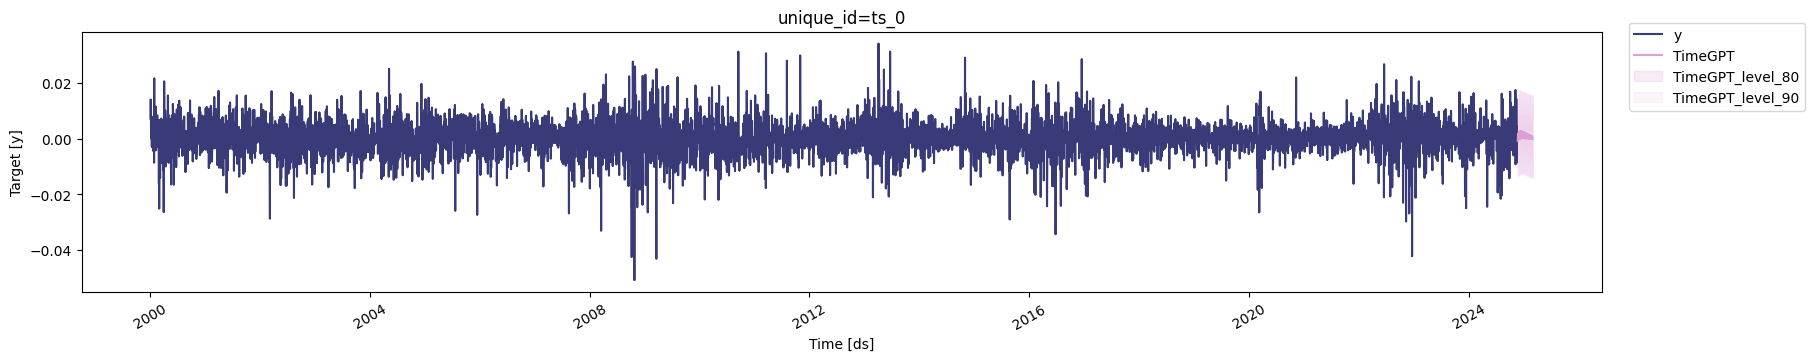

In [4]:
# Get your API Key at dashboard.nixtla.io

# 1. Instantiate the NixtlaClient
nixtla_client = NixtlaClient(api_key = api_key)

# 2. Read historic data
df = pd.read_csv('/Users/alexzheng/Developer/GitHub/Forecasting-Yen-Carry-Trade-Risk-Using-an-LLM/data/returns.csv')

# Reset the index to convert "Date" from the index to a column
df.reset_index(inplace=True)

# Rename columns to match Nixtla's format
df.rename(columns={'Date': 'ds', 'carry_trade_returns': 'y'}, inplace=True)
# Convert the "ds" column to datetime format (just in case)
df['ds'] = pd.to_datetime(df['ds'])


# 3. Forecast the next 100 days
fcst_df = nixtla_client.forecast(df, h=100, level=[80, 90])

# 4. Plot your results (optional)
nixtla_client.plot(df, fcst_df, level=[80, 90])


In [5]:
fcst_df.head(10)

,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-90,TimeGPT-lo-80,TimeGPT-lo-90
0,2024-11-21,-0.000778,0.008823,0.011668,-0.010379,-0.013224
1,2024-11-22,-0.000441,0.008679,0.012097,-0.009561,-0.012979
2,2024-11-23,0.000902,0.002579,0.003242,-0.000775,-0.001438
3,2024-11-24,0.001385,0.003425,0.003746,-0.000655,-0.000976
4,2024-11-25,0.001556,0.008589,0.010112,-0.005478,-0.007000
5,2024-11-26,0.001886,0.005889,0.010115,-0.002117,-0.006342
6,2024-11-27,0.001289,0.015837,0.016220,-0.013259,-0.013642
7,2024-11-28,0.000232,0.009833,0.012678,-0.009368,-0.012213
8,2024-11-29,0.000170,0.009290,0.012709,-0.008950,-0.012368
9,2024-11-30,0.001018,0.002695,0.003358,-0.000659,-0.001322


### Anomaly detection using TimeGPT in 3 easy steps

In [6]:
# # Get your API Key at dashboard.nixtla.io

# # 1. Instantiate the NixtlaClient
# nixtla_client = NixtlaClient(api_key = api_key)

# # 2. Read Data # Wikipedia visits of NFL Star (
# df = pd.read_csv('https://datasets-nixtla.s3.amazonaws.com/peyton-manning.csv')


# # 3. Detect Anomalies
# anomalies_df = nixtla_client.detect_anomalies(df, time_col='timestamp', target_col='value', freq='D')

# # 4. Plot your results (optional)
# nixtla_client.plot(df, anomalies_df,time_col='timestamp', target_col='value')